 ## Generate Tiff files for masks

In [ ]:
!pip install GDAL

In [1]:
from osgeo import gdal, osr
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import cv2

In [18]:
"""
1. load one from each tile from each location
2. grab shape
3. load each mask
4. match mask to image
5. resize image
"""

def return_image_paths(dir):

    """
    finds image paths from specific dates
    """
    image_paths = []

    dates = ['20210929']

    for filename in os.listdir(dir):
        for date in dates:
            if date in filename:
                image_path = os.path.join(dir, filename)
                image_paths.append(image_path)
                break
    return image_paths

def get_image_shape(path):
    """
    returns image shape
    * needed to resize mask to original image shape
    """
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    return (path.split('cropped_')[1][:15],img.shape)

def resize_mask_to_original_image_shape(image_path, output_shape):

    image = Image.open(image_path)
    image_array = np.array(image)

    # resize the image to the desired output shape
    resized_image = cv2.resize(image_array, output_shape, interpolation=cv2.INTER_AREA)
    resized_mask = np.where(resized_image > 0, 255, 0).astype(np.uint8)
    return resized_mask


def resize_image(info_list,path,name):
    for info in info_list:
        label = info[0]
        shape = info[1]
        if name+'_'+label in path:
            path = os.path.join('/content/drive/MyDrive/copernicus_data/new_deforestation_masks',path)
            resized_mask = resize_mask_to_original_image_shape(path,(shape[0],shape[1]))
    return resized_mask

In [22]:
### original image paths ###
"""
paths were seperated into 3 distinct locations
"""
mendocino_dir = '/content/drive/MyDrive/copernicus_data/mendocino_last_tci_image'
shastatrinity_dir = '/content/drive/MyDrive/copernicus_data/shastatrinity_last_tci_image'
sixrivers_dir = '/content/drive/MyDrive/copernicus_data/sixrivers_last_tci_image'

# get paths and shapes
mendocino_paths = return_image_paths(mendocino_dir)
mendocino_shape = [get_image_shape(path) for path in mendocino_paths]


shastatrinity_paths = return_image_paths(shastatrinity_dir)
shastatrinity_shape = [get_image_shape(path) for path in shastatrinity_paths]

sixrivers_paths = return_image_paths(sixrivers_dir)
sixrivers_shape =  [get_image_shape(path) for path in sixrivers_paths]



In [26]:
mask_paths = [f for f in os.listdir('/content/drive/MyDrive/copernicus_data/new_deforestation_masks')]
mask_paths

['shastatrinity_T10TDL_20210616_T10TDL_20210929_deforestation.jp2',
 'shastatrinity_T10TDK_20210616_T10TDK_20210929_deforestation.jp2',
 'shastatrinity_T10TEK_20210616_T10TEK_20210929_deforestation.jp2',
 'shastatrinity_T10TEL_20210616_T10TEL_20210929_deforestation.jp2',
 'shastatrinity_T10TEM_20210616_T10TEM_20210929_deforestation.jp2',
 'sixrivers_T10TDK_20210616_T10TDK_20210929_deforestation.jp2',
 'sixrivers_T10TDL_20210616_T10TDL_20210929_deforestation.jp2',
 'sixrivers_T10TDM_20210616_T10TDM_20210929_deforestation.jp2',
 'mendocino_T10SDJ_20210616_T10SDJ_20210929_deforestation.jp2',
 'mendocino_T10SEJ_20210616_T10SEJ_20210929_deforestation.jp2',
 'mendocino_T10TDK_20210616_T10TDK_20210929_deforestation.jp2',
 'mendocino_T10TEK_20210616_T10TEK_20210929_deforestation.jp2']

In [125]:
sixrivers_shape

[('T10TDM_20210929', (5976, 7867, 3)),
 ('T10TDL_20210929', (10980, 7867, 3)),
 ('T10TDK_20210929', (7017, 7867, 3))]

In [138]:
### load masks ###
"""
1. load image
2. convert to array
3. convert to binary mask 0 or 255
4. which can be normalized to 0 or 1
"""
tile_name = 'TDK'
location_name = 'sixrivers'
shape_index = 2

image = Image.open(f'/content/drive/MyDrive/copernicus_data/new_deforestation_masks/{location_name}_T10{tile_name}_20210616_T10{tile_name}_20210929_deforestation.jp2')
image_array = np.array(image)

tci_shape = sixrivers_shape[shape_index][1]

image_array = cv2.resize(image_array,(tci_shape[1],tci_shape[0]))
binary_mask = np.where(image_array > 0, 255, 0).astype(np.uint8)





### Find Metadata of Satellite Image

In [139]:
# open originali True Color Images from 2021/09/29
true_color_image = gdal.Open(f'/content/drive/MyDrive/copernicus_data/{location_name}_last_tci_image/cropped_T10{tile_name}_20210929T190201_TCI_10m.jp2')

In [140]:
### set paramters to georeference and correctly label masks
mask = binary_mask
TCI_image = true_color_image
name = f'{location_name}_{tile_name}'

In [141]:
# get metadata
metadata = TCI_image.GetMetadata()
for key, value in metadata.items():
    print(f"{key}: {value}")

# geotransform - retireves origin and pixel size
TCI_image_geotransform = TCI_image.GetGeoTransform()
print(f"Geotransform: {TCI_image_geotransform}")

# projection - use projection to set mask
TCI_image_projection = TCI_image.GetProjection()
print(f"Projection: {TCI_image_projection}")



Geotransform: (410550.0, 10.0, 0.0, 4500000.0, 0.0, -10.0)
Projection: PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]


In [142]:
output_file = f"/content/drive/MyDrive/copernicus_data/new_deforestation_tif_files/{name}.tif"


driver = gdal.GetDriverByName('GTiff')
rows, cols = mask.shape
dataset = driver.Create(output_file, cols, rows, 1, gdal.GDT_Byte)


geotransform = list(TCI_image_geotransform)
dataset.SetGeoTransform(geotransform)


# define projection
srs = osr.SpatialReference()
srs.ImportFromEPSG(32610) # 32610 is the overall projection
dataset.SetProjection(srs.ExportToWkt())

dataset.GetRasterBand(1).WriteArray(mask)
dataset.FlushCache()
dataset = None

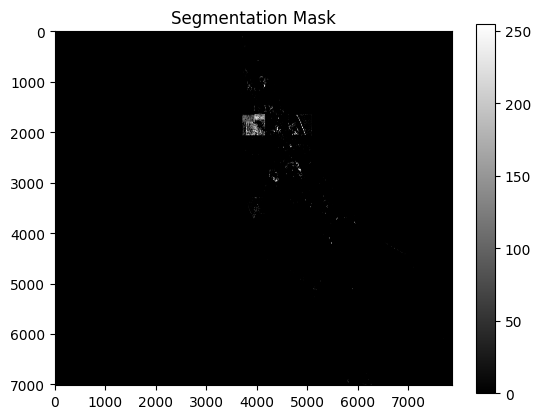

In [143]:
generated_tiff_file = f'/content/drive/MyDrive/copernicus_data/new_deforestation_tif_files/{name}.tif'

dataset = gdal.Open(generated_tiff_file)

# get the band
band = dataset.GetRasterBand(1)
array = band.ReadAsArray()


plt.imshow(array,cmap='gray')
plt.colorbar()
plt.title('Segmentation Mask')
plt.show()